In [ ]:
# Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
class MinimalCNN(nn.Module):
  """
  Minimal Fully Connected CNN Implementation:
  1 layer CNN (4 Feature Maps with Kernel Size 3) with ReLU activation
  1 layer Max Pool (Kernel Size 2 with Stride 2)
  1 layer Fully Connected (S)
  """
  def __init__(self):
    # Layer definition
    super(MinimalCNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=0, bias=True)

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.Linear(13 * 13 * 4, 10)

  def forward(self, x):
    # Forward Pass
    x = self.pool(F.relu(self.conv1(x))) # [batch, 4, 13, 13] (before pooling, size is [batch, 4, 26, 26])

    x = x.view(x.size(0), -1) # [batch, 676]

    x = self.fc1(x) # [batch, 10]

    return x

In [ ]:
# Training code
def train_model(epochs=10):

    # Transformations
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    # Load dataset
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

    # Create model w Adam optimizer and CrossEntropyLoss
    model = MinimalCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Set to train mode
    model.train()

    # Run epochs
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Go through batches
        for batch_idx, (data, targets) in enumerate(train_loader):
            optimizer.zero_grad() # set gradients to 0
            outputs = model(data) # output
            loss = criterion(outputs, targets) # compute loss
            loss.backward() # calculate gradients
            optimizer.step() # update weights

            # Update tracking loss
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            if batch_idx % 200 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')

        accuracy = 100 * correct / total
        print(f'Epoch {epoch+1} - Training Accuracy: {accuracy:.2f}%')

    # Evaluation
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in test_loader:
            outputs = model(data)
            test_loss += criterion(outputs, targets).item()
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_accuracy = 100 * correct / total
    print(f'\nTest Accuracy: {test_accuracy:.2f}%')

    return model, test_accuracy


In [ ]:
# Weight Quantization Function
def quantize_weights(model, bits=8):

  # Initialize model
  quantized_model = MinimalCNN()

  with torch.no_grad():
      # Convolutional weights
      conv_weight = model.conv1.weight.data
      conv_bias = model.conv1.bias.data

      # Scaling weights
      weight_scale = (2**(bits-1) - 1) / torch.max(torch.abs(conv_weight))
      bias_scale = (2**(bits-1) - 1) / torch.max(torch.abs(conv_bias))

      # Store quantized weights
      quantized_model.conv1.weight.data = torch.round(conv_weight * weight_scale) / weight_scale
      quantized_model.conv1.bias.data = torch.round(conv_bias * bias_scale) / bias_scale

      # Fully Connected Layer weights
      fc_weight = model.fc1.weight.data
      fc_bias = model.fc1.bias.data

      # Scaling weights
      fc_weight_scale = (2**(bits-1) - 1) / torch.max(torch.abs(fc_weight))
      fc_bias_scale = (2**(bits-1) - 1) / torch.max(torch.abs(fc_bias))

      # Store quantized weights
      quantized_model.fc1.weight.data = torch.round(fc_weight * fc_weight_scale) / fc_weight_scale
      quantized_model.fc1.bias.data = torch.round(fc_bias * fc_bias_scale) / fc_bias_scale

  return quantized_model, {
      'conv_weight_scale': weight_scale.item(),
      'conv_bias_scale': bias_scale.item(),
      'fc_weight_scale': fc_weight_scale.item(),
      'fc_bias_scale': fc_bias_scale.item()
  }


In [ ]:
# Function to export weights
def export_weights_for_systemverilog(model, scales):

    # Load weights
    conv_weights = model.conv1.weight.data.numpy()
    conv_bias = model.conv1.bias.data.numpy()

    # Print Weights
    print(f"Convolutional Layer Weights (4 filters, 3x3 each)")
    print(f"Shape: {conv_weights.shape}")
    for i in range(conv_weights.shape[0]):  # For each output channel
        print(f"Filter {i}")
        filter_weights = conv_weights[i, 0, :, :].flatten()
        weights_str = ", ".join([f"{w:.6f}" for w in filter_weights])
        print(f"parameter real CONV_WEIGHT_{i}[8:0] = '{{{weights_str}}};")

    print(f"Convolutional Layer Biases")
    bias_str = ", ".join([f"{b:.6f}" for b in conv_bias])
    print(f"parameter real CONV_BIAS[3:0] = '{{{bias_str}}};")

    # Export FC layer weights
    fc_weights = model.fc1.weight.data.numpy()
    fc_bias = model.fc1.bias.data.numpy()

    print(f"Fully Connected Layer")
    print(f"Weight matrix shape: {fc_weights.shape}") # shape of fc matmul

    # Weights per neuron
    for neuron_idx, neuron_weights in enumerate(fc_weights):
        weights_str = ", ".join([f"{w:.6f}" for w in neuron_weights])
        print(f"parameter real FC_WEIGHT_{neuron_idx}[{len(neuron_weights)-1}:0] = '{{{weights_str}}};")

    # Biases
    print(f"\n// FC Layer Biases")
    fc_bias_str = ", ".join([f"{b:.6f}" for b in fc_bias])
    print(f"parameter real FC_BIAS[9:0] = '{{{fc_bias_str}}};")

    # Quantization Scaling
    print(f"\n// Quantization scales for hardware implementation:")
    for key, value in scales.items():
        print(f"// {key}: {value}")

In [ ]:
model, accuracy = train_model()
quantized_model, scales = quantize_weights(model)
export_weights_for_systemverilog(quantized_model, scales)

100%|██████████| 9.91M/9.91M [00:00<00:00, 96.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 21.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 29.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.29MB/s]


Epoch 1, Batch 0, Loss: 2.3496
Epoch 1, Batch 200, Loss: 0.4369
Epoch 1, Batch 400, Loss: 0.2901
Epoch 1, Batch 600, Loss: 0.2756
Epoch 1, Batch 800, Loss: 0.3402
Epoch 1 - Training Accuracy: 89.56%
Epoch 2, Batch 0, Loss: 0.2947
Epoch 2, Batch 200, Loss: 0.3121
Epoch 2, Batch 400, Loss: 0.1075
Epoch 2, Batch 600, Loss: 0.3176
Epoch 2, Batch 800, Loss: 0.2393
Epoch 2 - Training Accuracy: 94.42%
Epoch 3, Batch 0, Loss: 0.0955
Epoch 3, Batch 200, Loss: 0.1544
Epoch 3, Batch 400, Loss: 0.1616
Epoch 3, Batch 600, Loss: 0.1477
Epoch 3, Batch 800, Loss: 0.2340
Epoch 3 - Training Accuracy: 95.74%
Epoch 4, Batch 0, Loss: 0.1017
Epoch 4, Batch 200, Loss: 0.1595
Epoch 4, Batch 400, Loss: 0.1307
Epoch 4, Batch 600, Loss: 0.0801
Epoch 4, Batch 800, Loss: 0.1085
Epoch 4 - Training Accuracy: 96.44%
Epoch 5, Batch 0, Loss: 0.0782
Epoch 5, Batch 200, Loss: 0.0596
Epoch 5, Batch 400, Loss: 0.2341
Epoch 5, Batch 600, Loss: 0.0914
Epoch 5, Batch 800, Loss: 0.0632
Epoch 5 - Training Accuracy: 96.77%
Epoch

In [ ]:
def eval_quantized_model(model, dataloader):
  # Evaluation
  criterion = nn.CrossEntropyLoss()
  model.eval()
  test_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
      for data, targets in test_loader:
          outputs = model(data)
          test_loss += criterion(outputs, targets).item()
          _, predicted = torch.max(outputs, 1)
          total += targets.size(0)
          correct += (predicted == targets).sum().item()

  test_accuracy = 100 * correct / total
  print(f'\nTest Accuracy: {test_accuracy:.2f}%')

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
quant_acc = eval_quantized_model(quantized_model, test_loader) ## NOTE: Just to verify the quantized model doesn't have significantly worse performace


Test Accuracy: 97.16%


In [ ]:
def quantize_tensor(x: torch.Tensor, bits: int = 8, eps: float = 1e-12):

    x_absmax = torch.max(torch.abs(x)).clamp_min(eps)
    qmax = (2 ** (bits - 1)) - 1
    scale = qmax / x_absmax
    q = torch.round(x * scale).clamp_(-qmax-1, qmax).to(torch.int8)
    x_hat = q.float() / scale
    return q, scale.item(), x_hat

def _to_numpy(x: torch.Tensor):
    return x.detach().cpu().numpy()

def _show_gray(img_2d, title):
    plt.figure()
    plt.imshow(img_2d, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

def inspect_random_sample(quantized_model, bits: int = 8, seed: int | None = None):
    """
    Random sample from MNIST inspected for intermediary outputs
    """
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
        np.random.seed(seed)

    # transforms match training
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    test_ds = datasets.MNIST("./data", train=False, download=True, transform=transform)
    idx = random.randrange(len(test_ds)) # random id
    (x_norm, y) = test_ds[idx] # normalized tensor
    # fetch the raw (unnormalized) image for display
    raw_ds = datasets.MNIST("./data", train=False, download=False, transform=transforms.ToTensor())
    x_raw, _ = raw_ds[idx]

    # show images
    _show_gray(_to_numpy(x_raw[0]), f"Raw MNIST (label={y})")
    _show_gray(_to_numpy(x_norm[0]), "Normalized MNIST")

    # print normalized array
    norm_arr = _to_numpy(x_norm[0])
    np.set_printoptions(precision=4, suppress=True, linewidth=140)
    print("Normalized image array [28x28]:")
    print(norm_arr)

    quantized_model.eval()

    # make into a batch
    x = x_norm.unsqueeze(0)  # [1,1,28,28]

    intermediates = {}

    # Conv
    conv_out = quantized_model.conv1(x) # [1,4,26,26]
    q_conv, s_conv, conv_deq = quantize_tensor(conv_out, bits)
    intermediates["conv_out_int8"] = q_conv
    intermediates["conv_scale"] = s_conv
    intermediates["conv_out_deq"] = conv_deq

    # ReLU
    relu_out = F.relu(conv_deq)
    q_relu, s_relu, relu_deq = quantize_tensor(relu_out, bits)
    intermediates["relu_out_int8"] = q_relu
    intermediates["relu_scale"] = s_relu
    intermediates["relu_out_deq"] = relu_deq

    # MaxPool
    pool_out = F.max_pool2d(relu_deq, kernel_size=2, stride=2) # [1,4,13,13]
    q_pool, s_pool, pool_deq = quantize_tensor(pool_out, bits)
    intermediates["pool_out_int8"] = q_pool
    intermediates["pool_scale"] = s_pool
    intermediates["pool_out_deq"] = pool_deq

    # Flatten
    flat = pool_deq.view(pool_deq.size(0), -1) # [1, 4*13*13=676]
    q_flat, s_flat, flat_deq = quantize_tensor(flat, bits)
    intermediates["flat_int8"] = q_flat
    intermediates["flat_scale"] = s_flat
    intermediates["flat_deq"] = flat_deq

    # Fully Connected
    logits = quantized_model.fc1(flat_deq) # [1,10]
    # (optionally quantize logits if needed to export them as int8)
    q_logits, s_logits, logits_deq = quantize_tensor(logits, bits)
    intermediates["logits_int8"] = q_logits
    intermediates["logits_scale"] = s_logits
    intermediates["logits_deq"] = logits_deq
    pred = logits_deq.argmax(dim=1).item()

    # Summaries
    def head(t, n=10):
        a = _to_numpy(t).reshape(-1)
        n = min(n, a.size)
        return a[:n]

    print("\n--- Intermediates (shapes / int8 head / scale) ---")
    print(f"conv_out:     {_to_numpy(conv_out).shape}, int8 head={head(q_conv)},   scale={s_conv:.6f}")
    print(f"relu_out:     {_to_numpy(relu_out).shape}, int8 head={head(q_relu)},   scale={s_relu:.6f}")
    print(f"pool_out:     {_to_numpy(pool_out).shape}, int8 head={head(q_pool)},   scale={s_pool:.6f}")
    print(f"flatten:      {_to_numpy(flat).shape},     int8 head={head(q_flat)},   scale={s_flat:.6f}")
    print(f"logits (deq): {_to_numpy(logits_deq).shape}, values={_to_numpy(logits_deq)[0]}")
    print(f"Predicted label = {pred} (true={y})")

    # 4) for SV export examples: first feature-map slice as int8 matrix
    # (this gives you a realistic activation tensor you could route in RTL)
    conv_int8_fm0 = _to_numpy(q_conv[0, 0])   # [26,26]
    pool_int8_fm0 = _to_numpy(q_pool[0, 0])   # [13,13]
    print("\nconv_out (feature map 0) int8 [26x26] sample:")
    print(conv_int8_fm0)
    print("\npool_out (feature map 0) int8 [13x13] sample:")
    print(pool_int8_fm0)

    return {
        "index": idx,
        "label_true": int(y),
        "label_pred": int(pred),
        "normalized_image": norm_arr,
        "intermediates": intermediates
    }

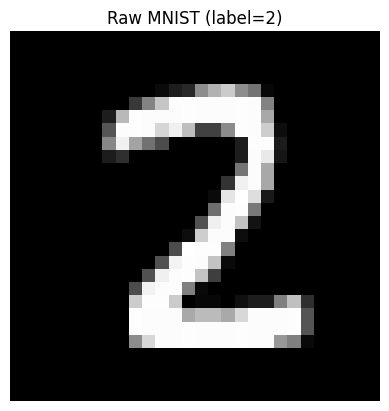

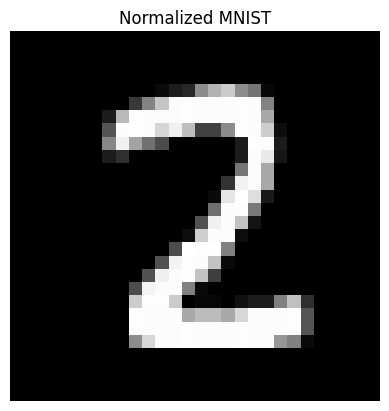

Normalized image array [28x28]:
[[-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242
  -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242]
 [-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242
  -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242]
 [-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242
  -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242]
 [-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242
  -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242]
 [-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0

In [ ]:
out = inspect_random_sample(quantized_model, bits=8, seed=42)